In [1]:
from explore_import import  *
import ionbot_preprocess as io
import data_preprocess as dt
import hpp_checker as hpp
from Download_UnimodDB import *
import tpp_preprocess as tpp

from pyteomics import mass
import itertools 
from itertools import combinations
import time
import re
import ast
from scipy.spatial import distance
from gql import gql, Client
from gql.transport.aiohttp import AIOHTTPTransport
import asyncio
import plotly.graph_objects as go
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
import scipy

In [3]:
# GLOBAL VARS
PIPELINE = 'ionbot_open'
PIPELINE_LW = PIPELINE.lower()

In [4]:
#base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths=dt.list_files(processed_dir)
# leave only non-entrapment and open search, only search files
tmp = processed_paths.copy()
for parent, files in processed_paths.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths = tmp

# where to save pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"

# 
plot_dir = f"{root}/oui-discovery-vv-plot/{PIPELINE_LW}"

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

In [5]:
def get_peptide_position(database_peptide, protein, OPfasta):
    count_var=0
    #print(database_peptide, protein, count_var)
    prot_seq=str(OPfasta[protein].seq)
    pos=hpp.get_pep_positions(prot_seq, database_peptide)
    if len(pos)>1: pos=[pos[0]] #take first occurance in protein
    if len(pos)==0: #if didnt find peptide in protein
        # try L->I
        database_peptide = database_peptide.replace('L','I')
        prot_seq=str(OPfasta[protein].seq)
        pos=hpp.get_pep_positions(prot_seq, database_peptide)
        if len(pos)>1: pos=[pos[0]]
        if len(pos)==0:
            count_var+=1;  pos=[np.nan]
    if count_var > 0: print(database_peptide, protein, count_var)
    return pos[0]

In [6]:
OPfasta_file="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/concatenated-fastas/20241102-openprot-database_ionbot_db/concat.fasta"
input_file = open(OPfasta_file)
OPfasta = SeqIO.to_dict(SeqIO.parse(OPfasta_file, "fasta"))

#### Load PSM

In [7]:
psm_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            
            psm_filt += [data]
psm_filt = pd.concat(psm_filt)
# NOTE: decoys are retained
psm_filt = psm_filt[(psm_filt['q.value'] < 0.01)&(psm_filt['isCanonical'] != 'Contam')]

# str to list
psm_filt['proteins'] = psm_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
psm_filt['isProteotypic'] = psm_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
psm_filt["peptide_class"]=psm_filt["proteins"].apply(tpp.classify_peptide_tpp)

/tmp/ipykernel_202818/3085054410.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))
/tmp/ipykernel_202818/3085054410.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))


#### Load peptide

In [8]:
pep_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_filt += [data]
pep_filt = pd.concat(pep_filt)
# NOTE: only target peptides are left
pep_filt = pep_filt[(pep_filt['subset_max_rank'] == True)&(pep_filt['isCanonical'] != 'Contam')]

# str to list
#pep_filt['protein'] = pep_filt['protein'].apply(lambda x: ast.literal_eval(x))
pep_filt['proteins'] = pep_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
pep_filt['isProteotypic'] = pep_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
pep_filt["peptide_class"]=pep_filt["proteins"].apply(tpp.classify_peptide_tpp)

#### Merge PSM and peptide

In [9]:
# Select PSM maching peptide level 
psmpep_filt_op = psm_filt[psm_filt['search_database'] == 'openprot']
print('All OP psm', len(psmpep_filt_op))
psmpep_filt_op = psmpep_filt_op[psmpep_filt_op['database_peptide'].isin(pep_filt[pep_filt['search_database'] == 'openprot']['database_peptide'].tolist())]
psmpep_filt_op.reset_index(drop=True,inplace=True)
print('Peptide-level psm', len(psmpep_filt_op))
# Select proteotypic non-canonical peptides-psm
psmpep_prnc=psmpep_filt_op[psmpep_filt_op.peptide_class=="unique_to_Noncanon"]
print('Proteotypic non-canon peptide-level psm',len(psmpep_prnc))

All OP psm 323529
Peptide-level psm 313941
Proteotypic non-canon peptide-level psm 4568


In [10]:
del psmpep_filt_op

In [11]:
#add peptide length and parse peptide position
psmpep_prnc["peptide_length"]=psmpep_prnc.database_peptide.apply(lambda x: len(x))

# indicate peptide position
psmpep_prnc["peptide_position"]='nan'
psmpep_prnc['peptide_position'] = psmpep_prnc.apply(lambda x: get_peptide_position(x['database_peptide'], x['proteins'][0], OPfasta), axis=1)

#### Annotate modifications

In [12]:
def PTM_string_to_masses_list(ptm_string, unimod):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    x = {a:re.split('[][]',b) for a,b in x}
    x = [(int(a),b[3],int(b[1])) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod)) for a,b,c in x]    
    return x
#Modify to parce 9999 not by unimod_id but by code_name
def PTM_string_to_masses_list_9999(ptm_string, unimod, unimod_df):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    #print(ptm_string)
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    #print(x)
    x = {a:re.split('[][]',b) for a,b in x}
    #print(x)
    x = [(int(a),b[3],int(b[1]) if "9999" not in b[1] else b[2]) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod) if not isinstance(c,str) 
          else float(unimod_df[unimod_df.code_name==c].mono_mass.iloc[0]) if c in unimod_df.code_name.tolist()
         else np.nan) for a,b,c in x]    
    return x

In [13]:
def Download_Unimod_Dict_names():
    unimod = Download_UnimodDB()
    condensed_unimod = {}
    for uni_id,df in unimod.groupby("unimod_id").__iter__():
        condensed_unimod[uni_id] = {}
        condensed_unimod[uni_id]['residues'] = "".join([_ for _ in df.residue if '-' not in _])
        condensed_unimod[uni_id]['mono_mass'] = [_ for _ in set(df.mono_mass)][0]
        condensed_unimod[uni_id]['code_name'] = [_ for _ in set(df.code_name)][0]
        condensed_unimod[uni_id]['full_name'] = [_ for _ in set(df.full_name)][0]
        condensed_unimod[uni_id]['classification'] = [_ for _ in set(df.classification)][0]
        
    return condensed_unimod

In [14]:
# 3-letter to 1-letter amino acid mapping
aa_map = {
    "Ala": "A", "Cys": "C", "Asp": "D", "Glu": "E", "Phe": "F",
    "Gly": "G", "His": "H", "Ile": "I", "Lys": "K", "Leu": "L",
    "Met": "M", "Asn": "N", "Pro": "P", "Gln": "Q", "Arg": "R",
    "Ser": "S", "Thr": "T", "Val": "V", "Trp": "W", "Tyr": "Y",
    "Xle": "L",  # Xle usually refers to Leu/Ile, mapped to Leu ("L") here
    "CamCys": "C", "MetOx": "M"  # Optional: include PTMs if needed
}

# Your list of mutations
mutations = ['His2Asn', 'His2Asp', 'Ala->Ser', 'Ala->Thr', 'Ala->Asp', ...]  # etc.

# Function to extract 1-letter code of the target amino acid
def extract_target_aa(mutation):
    if "->" in mutation:
        target = mutation.split("->")[1]
    elif "2" in mutation:
        target = mutation.split("2")[1]
    else:
        return None  # or raise error if unexpected format

    return aa_map.get(target, "?")  # return '?' if unknown

In [15]:
unimod = Download_Unimod_Dict_names()
unimod_df=pd.DataFrame.from_dict(unimod, orient='index')
#mark substitutions
unimod_df["isSubstitution"]=unimod_df.full_name.apply(lambda x: "substitution" in x)
unimod_df_subs=unimod_df[unimod_df["isSubstitution"]]
#to what residue is change
unimod_df_subs["subs_to_residue"]=unimod_df_subs.code_name.apply(lambda x: extract_target_aa(x))

/tmp/ipykernel_202818/210214903.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unimod_df_subs["subs_to_residue"]=unimod_df_subs.code_name.apply(lambda x: extract_target_aa(x))


In [16]:
# Remove retention times in parentheses
psmpep_prnc['modifications_noRT'] = psmpep_prnc['modifications'].str.replace(r'\([^)]*\)', '', regex=True)

# Convert modifications to mass lists
psmpep_prnc['modifications_masses'] = psmpep_prnc['modifications'].map(
    lambda x: PTM_string_to_masses_list_9999(x, unimod, unimod_df)
)

# Extract list of masses and total mass shift in one pass
def extract_mass_info(mods):
    if mods == 'Unmodified':
        return [0], 0
    masses = [mod[2] for mod in mods]
    return masses, np.sum(masses)

mass_info = psmpep_prnc['modifications_masses'].map(extract_mass_info)
psmpep_prnc[['masses', 'tot_mass_shift']] = pd.DataFrame(mass_info.tolist(), index=psmpep_prnc.index)
psmpep_prnc['tot_mass_shift'] = psmpep_prnc['tot_mass_shift'].fillna(0)

# Precompute lookups for substitutions and classification
mass_to_residues = unimod_df_subs.groupby('mono_mass')['residues'].apply(set).to_dict()
mass_to_class = unimod_df.groupby('mono_mass')['classification'].apply(list).to_dict()
known_sub_masses = set(mass_to_residues.keys())

def has_substitution(peptide, masses):
    for m in masses:
        if m in known_sub_masses:
            residues = mass_to_residues[m]
            if any(aa in residues for aa in peptide):
                return True
    return False

psmpep_prnc['isSubstitution'] = [
    has_substitution(peptide, masses)
    for peptide, masses in zip(psmpep_prnc['database_peptide'], psmpep_prnc['masses'])
]

psmpep_prnc['masses_classification'] = psmpep_prnc['masses'].map(
    lambda masses: [mass_to_class.get(m, []) for m in masses]
)

### HPP guidlines - peptide level

In [17]:
def filter_nested_intervals(intervals):
    if len(intervals)==1: return True
    # Sort by start ascending, and end descending to prioritize wider intervals
    #unpack the list
    #intervals=[i[0] for i in intervals]
    sorted_intervals = sorted(intervals, key=lambda x: (x[0], -x[1]))
    result = []
    for i, (start_i, end_i) in enumerate(sorted_intervals):
        is_nested = False
        for j, (start_j, end_j) in enumerate(sorted_intervals):
            if i != j and start_j <= start_i and end_i <= end_j:
                is_nested = True
                break
        if not is_nested:
            result.append((start_i, end_i))
    result_bool=[i in result for i in intervals]
    return result_bool
def filter_short_overlaps(i,overlapping_intervals,minimal_length):
    indexes,intervals = overlapping_intervals
    for indx,interval in zip(indexes,intervals):
        if i in indx and len(indx)==1:
            return True
        elif i in indx and len(indx)>1:
            return abs(interval[0]-interval[1])>=minimal_length
        else:
            continue

In [18]:
def track_hpp_countdown(countdown_dict, newkey, pepdf, psmdf):
    countdown_dict["psm"][newkey]=len(psmdf[psmdf.database_peptide.isin(pepdf.database_peptide.tolist())])
    countdown_dict["pep"][newkey]=len(pepdf)
    countdown_dict["prot"][newkey]=len(pepdf.leadprot.unique())
    return countdown_dict
    
def is_goodlength(df,min_length=9):
    '''Filteres out peptides with length shorter than minimal.'''
    return df[df.peptide_length>=min_length]

def is_nonnested(df):
    '''Filteres out sub-peptides. Apply only on proteotypic peptides.'''
    df["NonNested"] = df.groupby("leadprot")["peptide_position"].transform(
        lambda intervals: filter_nested_intervals(intervals.values)
    )
    return df[df["NonNested"]]

def mark_overlaps(group,minimal_length=18):
    intervals = group.peptide_position.values
    if len(intervals) == 1:
        group["overlap_intervals"] = [True] * len(group)
    else:
        #unpack the list
        #intervals=[i[0] for i in intervals]
        overlapping_intervals = hpp.find_max_length_in_overlap_groups(intervals)
        good_overlap = [
            filter_short_overlaps(i, overlapping_intervals, minimal_length) 
            for i in range(len(group))
        ]
        group["overlap_intervals"] = good_overlap
    return group

def is_nonoverlap(df):
    df = df.groupby("leadprot", group_keys=False).apply(mark_overlaps)
    return df[df.overlap_intervals]
    
def check_2_pep(group):
    return len(group)>=2

def is_2pep(df):
    df["isProt2Pep"]=df.leadprot.apply(lambda x: check_2_pep(df.groupby("leadprot").get_group(x)))
    return df[df.isProt2Pep]

In [19]:
#track how many we loose with each HPP criteria
hpp_countdown={"psm":{},"pep":{},"prot":{}}

In [20]:
#track
hpp_countdown["psm"]["original"]=len(psmpep_prnc)
hpp_countdown["pep"]["original"]=len(psmpep_prnc.drop_duplicates("database_peptide"))
hpp_countdown["prot"]["original"]=len(psmpep_prnc.leadprot.unique())

#### Peptide level

In [21]:
psmpep_prnc_pepfilt=psmpep_prnc.copy(deep=True)

#Go to peptide level - leave 1 PSM per peptide
psmpep_prnc_pepfilt.drop_duplicates("database_peptide",inplace=True)

#Filter out peptides <9 aa long
psmpep_prnc_pepfilt=is_goodlength(psmpep_prnc_pepfilt)
psmpep_prnc["<9aa"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())
#track <9aa
hpp_countdown=track_hpp_countdown(hpp_countdown, "<9aa", psmpep_prnc_pepfilt, psmpep_prnc)

#Filter out nested peptides
psmpep_prnc_pepfilt=is_nonnested(psmpep_prnc_pepfilt)
psmpep_prnc["nested"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())

#track nested
hpp_countdown=track_hpp_countdown(hpp_countdown, "nested", psmpep_prnc_pepfilt, psmpep_prnc)

#For overlapping peptides, check the total extent length is >=18
psmpep_prnc_pepfilt=is_nonoverlap(psmpep_prnc_pepfilt)
psmpep_prnc["<18aa"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())

#track <18aa
hpp_countdown=track_hpp_countdown(hpp_countdown, "<18aa", psmpep_prnc_pepfilt, psmpep_prnc)

In [22]:
#Filter out peptides, that are non-unqiely maped to peptide variants

#Input to the list into https://hppportal.net/toolchecker.html
#for pep in psmpep_prnc_pepfilt.database_peptide:
#    print(pep)
#psmpep_prnc_pepfilt["database_peptide"].to_csv(f"{results_dir}/nc_uniqness_check.csv", index=False, header=False)

In [23]:
#read the output
uniqness_checker=pd.read_csv(f"{results_dir}/nc_uniqnesschecker_res.csv")
uniqness_checker["NoMatch"]=uniqness_checker['Subject Accession']=='NO MATCH'
#mark uniqness
psmpep_prnc_pepfilt=psmpep_prnc_pepfilt.merge(uniqness_checker[["Peptide","NoMatch"]],left_on="database_peptide",right_on="Peptide",how="left")
psmpep_prnc_pepfilt=psmpep_prnc_pepfilt[psmpep_prnc_pepfilt.NoMatch!=False]
psmpep_prnc["uniqness"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())

#track uniqness
hpp_countdown=track_hpp_countdown(hpp_countdown, "uniqness", psmpep_prnc_pepfilt, psmpep_prnc)

#check for unique 2 peptides, filterout if not
psmpep_prnc_pepfilt=is_2pep(psmpep_prnc_pepfilt)
psmpep_prnc["2pep1"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())

#track min 2 proteotypic peptides per protein
hpp_countdown=track_hpp_countdown(hpp_countdown, "2pep1", psmpep_prnc_pepfilt, psmpep_prnc)

In [24]:
hpp_countdown

{'psm': {'original': 4568,
  '<9aa': 4422,
  'nested': 3429,
  '<18aa': 3429,
  'uniqness': 977,
  '2pep1': 113},
 'pep': {'original': 528,
  '<9aa': 515,
  'nested': 449,
  '<18aa': 449,
  'uniqness': 150,
  '2pep1': 12},
 'prot': {'original': 420,
  '<9aa': 412,
  'nested': 412,
  '<18aa': 412,
  'uniqness': 144,
  '2pep1': 6}}

In [25]:
# tmp checkpoint
#psmpep_prnc_pepfilt.to_pickle(f'{results_dir}/psmpep_prnc_pepfilt.pkl')

In [26]:
#psmpep_prnc_pepfilt=pd.read_pickle(f'{results_dir}/psmpep_prnc_pepfilt.pkl')

### Diagnostic features plot

#### --- HPP-pass (untill first 2 unique peptides step) ---

In [27]:
psmpep_prnc_2pep1 = psmpep_prnc[psmpep_prnc['2pep1']].copy(deep=True)

In [28]:
psmpep_prnc_2pep1.leadprot.unique()

array(['IP_602534', 'IP_761691', 'IP_595307', 'IP_762589', 'IP_592206',
       'IP_572520'], dtype=object)

#### PSM and OpenProt MS score

In [29]:
OPtsv_file=f"{root}/oui-discovery-vv-data/raw/ionbot_openprot/human-openprot-2_0-refprots+altprots+isoforms-uniprot2022_06_01.tsv"
OPtsv=pd.read_csv(OPtsv_file,sep="\t",header=None)
OPtsv.columns=["protein accession","protein accession (others)","protein type","protein length (a.a.)",
               "molecular weight (kDa)","isoelectric point","frame","gene symbol","chr","start genomic coordinates",
               "stop genomic coordinates","strand","transcript accession","type","localization","start transcript coordinates",
               "stop transcript coordinates","MS score","TE Translation Event score","Orthology Across 10 Species #:Species Names",
               "Kozak motif","High-efficiency TIS motif"]#,"Domains"]
#Trimm version number from ENS identifier
#OPtsv["trx_stab"]=OPtsv["transcript accession"].str[0:15]
OPtsv = OPtsv[OPtsv['protein accession'].isin(psmpep_prnc_2pep1.leadprot.unique().tolist())]

/tmp/ipykernel_202818/3705688082.py:2: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  OPtsv=pd.read_csv(OPtsv_file,sep="\t",header=None)


In [30]:
OPtsv

,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,transcript accession,type,localization,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Orthology Across 10 Species #:Species Names,Kozak motif,High-efficiency TIS motif
1848794,IP_572520,IP_572520,AltProt,178,20.01,5.64,1,RPL5P22,8,28299832,...,ENST00000480199.1,misc_RNA,-,151,688,10,0,-,-,6
1884798,IP_592206,IP_592206,AltProt,119,13.79,10.43,1,RPS27AP11,6,113581500,...,ENST00000402798.1,misc_RNA,-,1,361,7,0,-,-,11
1890809,IP_595307,IP_595307,AltProt,139,16.18,4.11,3,KRT8P43,6,24598913,...,ENST00000406052.2,misc_RNA,-,582,1002,3,0,+,-,8
1902842,IP_602534,IP_602534,AltProt,203,23.90,4.56,2,KRT8P32,5,98392737,...,ENST00000512863.1,misc_RNA,-,182,794,13,0,+,-,13
2203033,IP_761691,IP_761691,AltProt,448,48.79,6.82,1,HSPD1P4,12,56511001,...,ENST00000547203.1,misc_RNA,-,1,1348,34,0,-,-,12
2204363,IP_762589,IP_762589,AltProt,296,31.93,9.36,1,EEF1A1P4,12,19456244,...,ENST00000359165.5,misc_RNA,-,514,1405,19,0,-,-,11


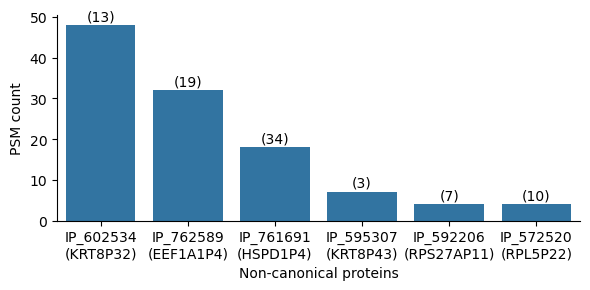

In [31]:
# psm suport? - barplot

# Count PSMs per leadprot
counts = psmpep_prnc_2pep1['leadprot'].value_counts()
order = counts.index.tolist()

# Reorder OPtsv to match leadprot order
OPtsv["protein accession"] = pd.Categorical(OPtsv["protein accession"], categories=order, ordered=True)
OPtsv = OPtsv.sort_values("protein accession")

# Create custom x-axis labels: "protein accession (gene symbol)"
xticks = OPtsv.apply(lambda x: f'{x["protein accession"]}\n({x["gene symbol"]})', axis=1).tolist()

# Extract the MS scores in same order
ms_scores = OPtsv["MS score"].tolist()

# --- PLOT ---
plt.figure(figsize=(6, 3))
ax = sns.barplot(x=counts.index, y=counts.values)
sns.despine()

plt.xlabel("Non-canonical proteins")
plt.ylabel("PSM count")
plt.xticks(range(len(xticks)), xticks, rotation=0, ha="center")

# --- Add MS score text above each bar ---
for i, (count, ms) in enumerate(zip(counts.values, ms_scores)):
    ax.text(i, count + 0.5, f"({ms})", ha="center", va="bottom", fontsize=10, color="black")

plt.tight_layout()
plt.savefig(f"{plot_dir}/nc_passhpp_psm.svg",format='svg', bbox_inches = 'tight')

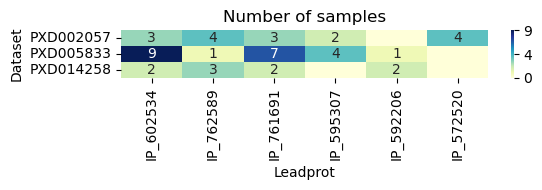

In [32]:
# dataset (per sample) support - heatmap
df = psmpep_prnc_2pep1.drop_duplicates(['leadprot','spectrum_file']).groupby('leadprot')[['dataset']].value_counts().reset_index()
df['dataset'] = df['dataset'].str.replace('.v0.11.4','')
protein_order = psmpep_prnc_2pep1['leadprot'].value_counts().index.tolist()

pivot_df = df.pivot(index='dataset', columns='leadprot', values='count').fillna(0)
pivot_df = pivot_df[protein_order]

plt.figure(figsize=(6, 2))

# Replace 0 with empty string
annot = pivot_df.applymap(lambda v: "" if v == 0 else f"{int(v)}")

ax = sns.heatmap(pivot_df, annot=annot, fmt="", cmap="YlGnBu", cbar=True)

# Access the colorbar safely
mappable = ax.collections[0]
cbar = mappable.colorbar

# Compute min, mid, max
vmin, vmax = pivot_df.values.min(), pivot_df.values.max()
vmid = (vmin + vmax) / 2

# Set ticks to min, mid, max
cbar.set_ticks([vmin, vmid, vmax])
cbar.set_ticklabels([f"{vmin:.0f}", f"{vmid:.0f}", f"{vmax:.0f}"])

plt.title("Number of samples")
plt.xlabel("Leadprot")
plt.ylabel("Dataset")
plt.tight_layout()
plt.savefig(f"{plot_dir}/nc_passhpp_repr.svg",format='svg', bbox_inches = 'tight')

#### mass error (ppm)

In [33]:
# Calculate ppm mass error
psmpep_prnc_2pep1["mass_error_ppm"] = ((psmpep_prnc_2pep1["precursor_mass"] - psmpep_prnc_2pep1["peptide_mass"]) / psmpep_prnc_2pep1["peptide_mass"]) * 1e6

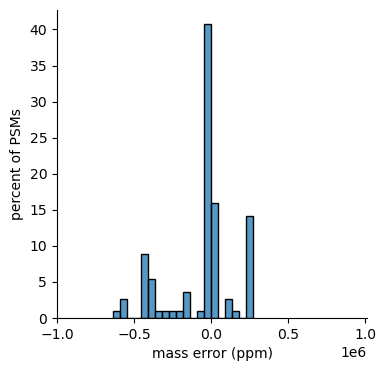

In [34]:
fig, ax = plt.subplots(figsize=(4,4))
sns.histplot(ax=ax,data=psmpep_prnc_2pep1, x="mass_error_ppm",stat="percent", bins=20);
sns.despine();
ax.set_xlim(-1* 1e6,1.01* 1e6)
ax.set_xlabel("mass error (ppm)");
ax.set_ylabel("percent of PSMs");
plt.savefig(f"{plot_dir}/nc_passhpp_ppm.svg",format='svg', bbox_inches = 'tight')

#### observed and predicted retention time correlation

In [35]:
# read feature files

features_files = []  # files ending with -openprot-combined-features.csv.gz
for dirpath, dirnames, filenames in os.walk(processed_dir):
    # Check directories ending with ".v0.11.4" - open search results
    if dirpath.split('/')[-2].endswith(".v0.11.4"):    
        # Check for files ending with "-openprot-combined-features.csv.gz"
        for filename in filenames:
            if filename.endswith("-openprot-combined-features.csv.gz"):
                print(filename)
                features_files.append(os.path.join(os.path.abspath(dirpath), filename))

features_op = pd.concat([pd.read_csv(_) for _ in features_files])
##features_op['spectrum_title'] = features_op.apply(lambda x: x.+':'+x['spectrum_title'] if not ':' in x['spectrum_title'], axis=1)
features_op['spectrum_file'] = features_op['spectrum_file'].str.replace('ESC-HF-','')
features_op['spectrum_file'] = features_op['spectrum_file'].apply(lambda x: x[:-1].replace('_','') if 'Sample' in x else x)

PXD005833.v0.11.4-openprot-combined-features.csv.gz
PXD002057.v0.11.4-openprot-combined-features.csv.gz
PXD014258.v0.11.4-openprot-combined-features.csv.gz


In [36]:
# select HPP-pass PSM
features_op_2pep1 = features_op.merge(psmpep_prnc_2pep1[['spectrum_title','spectrum_file','observed_retention_time','database_peptide']], on=['spectrum_title','spectrum_file'],how='right')

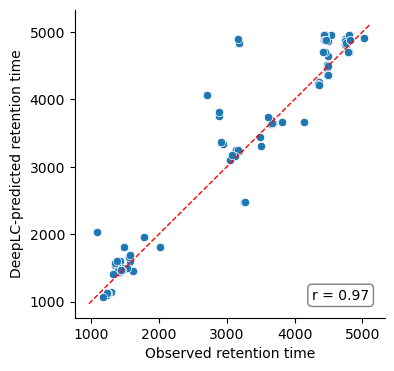

In [37]:
# Get the range of x and y for a proper diagonal
min_val = min(features_op_2pep1["observed_retention_time"].min(),
              features_op_2pep1["predicted_retention_time"].min()) - 100
max_val = max(features_op_2pep1["observed_retention_time"].max(),
              features_op_2pep1["predicted_retention_time"].max()) +100

# Create figure and plot
fig, ax = plt.subplots(figsize=(4, 4))

# Scatter plot
sns.scatterplot(ax=ax, data=features_op_2pep1, 
                x="observed_retention_time", 
                y="predicted_retention_time")

# Plot diagonal line (y = x)
ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=1)

res=scipy.stats.pearsonr(features_op_2pep1.observed_retention_time,features_op_2pep1.predicted_retention_time)
# Format the correlation value (e.g., r = 0.95, p = 0.0001)
textstr = f"r = {res.statistic:.2f}"

# Add text in lower-right corner of the axes
ax.text(0.95, 0.05, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='bottom',
        horizontalalignment='right',
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

# Style
sns.despine()
ax.set_xlabel("Observed retention time")
ax.set_ylabel("DeepLC-predicted retention time")

# Save
plt.savefig(f"{plot_dir}/nc_passhpp_rettimeerror.svg", format='svg', bbox_inches='tight')

#### --- gnomAD and intensity correlation

In [38]:
# generated by explore-3-gnomAD
isosaaav_info = pd.read_pickle(f'{results_dir}/{PIPELINE_LW}_psmpep_isosaaav.pkl')
isosaaav_info = isosaaav_info[isosaaav_info['database_peptide'].isin(psmpep_prnc_2pep1.database_peptide.tolist())]

In [39]:
aminoacid_table={
    'A': ['GCT', 'GCC', 'GCA', 'GCG'],  # Alanine
    'R': ['CGT', 'CGC', 'CGA', 'CGG', 'AGA', 'AGG'],  # Arginine
    'N': ['AAT', 'AAC'],  # Asparagine
    'D': ['GAT', 'GAC'],  # Aspartic acid
    'C': ['TGT', 'TGC'],  # Cysteine
    'Q': ['CAA', 'CAG'],  # Glutamine
    'E': ['GAA', 'GAG'],  # Glutamic acid
    'G': ['GGT', 'GGC', 'GGA', 'GGG'],  # Glycine
    'H': ['CAT', 'CAC'],  # Histidine
    'I': ['ATT', 'ATC', 'ATA'],  # Isoleucine
    'L': ['TTA', 'TTG', 'CTT', 'CTC', 'CTA', 'CTG'],  # Leucine
    'K': ['AAA', 'AAG'],  # Lysine
    'M': ['ATG'],  # Methionine (Start codon)
    'F': ['TTT', 'TTC'],  # Phenylalanine
    'P': ['CCT', 'CCC', 'CCA', 'CCG'],  # Proline
    'S': ['TCT', 'TCC', 'TCA', 'TCG', 'AGT', 'AGC'],  # Serine
    'T': ['ACT', 'ACC', 'ACA', 'ACG'],  # Threonine
    'W': ['TGG'],  # Tryptophan
    'Y': ['TAT', 'TAC'],  # Tyrosine
    'V': ['GTT', 'GTC', 'GTA', 'GTG'],  # Valine
    '*': ['TAA', 'TAG', 'TGA']  # Stop codons
}


def dist_1(refcod,cods):
    res=[]
    for cod in cods:
        if np.sum([1 for a,b in zip(cod,refcod) if a!=b])==1:
            res.append(cod)
    return res
def diff_1_bp(refcod,cods):
    res=[]
    for cod in cods:
        res.append([i for i,(a,b) in enumerate(zip(cod,refcod)) if a!=b][0])
    return res

In [40]:
print('target genomic pos','codon','codons lookup in gnomAD')
for i,row in isosaaav_info.iterrows():
    refcode = row.saav_info_refcod if row.strand==1 else row.saav_info_refcod_rev
    #refcode =  np.array(refcode)[row.is_expected_aa]
    triplet = row.saav_info_triplet #np.array(row.saav_info_triplet)[row.is_expected_aa]
    is_exp = row.is_expected_aa
    altpep = row.peptides_w1sub
    prints=[ [ np.array(i[0])[diff_1_bp(''.join(ii[0]), dist_1(''.join(ii[0]),aminoacid_table[ii[1]]))],
            ''.join(ii[0]), 
            dist_1(''.join(ii[0]),aminoacid_table[ii[1]]),
               iv
          ] for i, ii, iii, iv in zip(triplet,refcode, is_exp, altpep) 
          if iii and len(dist_1(''.join(ii[0]),aminoacid_table[ii[1]]))>0]
    if prints:
        print(i,'-', row.database_peptide, row.proteins)
        print(row.chromosome)
        print(prints)

target genomic pos codon codons lookup in gnomAD
1053 - ALMLQGIDLLADAVALTMGPKGR ['IP_761691']
12
[[array([56511113]), 'GCC', ['TCC'], 'SLMLQGIDLLADAVALTMGPKGR'], [array([56511143]), 'GCC', ['TCC'], 'ALMLQGIDLLSDAVALTMGPKGR'], [array([56511149]), 'GCT', ['TCT'], 'ALMLQGIDLLADSVALTMGPKGR'], [array([56511155]), 'GCC', ['TCC'], 'ALMLQGIDLLADAVSLTMGPKGR']]
8905 - LQSQIWDTSVVLSMDNSWSLDMDSIIAEVK ['IP_595307']
6
[[array([24599133]), 'GCT', ['TCT'], 'LQSQIWDTSVVLSMDNSWSLDMDSIISEVK']]
9696 - MEVTGDEYNVENIDGQPGAFTCYLDAGLAR ['IP_572520']
8
[[array([28300103]), 'GCC', ['TCC'], 'MEVTGDEYNVENIDGQPGSFTCYLDAGLAR'], [array([28300107]), 'TTT', ['TAT'], 'MEVTGDEYNVENIDGQPGAYTCYLDAGLAR'], [array([28300124]), 'GCA', ['TCA'], 'MEVTGDEYNVENIDGQPGAFTCYLDSGLAR'], [array([28300133]), 'GCC', ['TCC'], 'MEVTGDEYNVENIDGQPGAFTCYLDAGLSR']]
9752 - MGGITAITFNQSLLSPLNLEVDPNIQAVR ['IP_602534']
5
[[array([98393334]), 'GCC', ['TCC'], 'MGGITSITFNQSLLSPLNLEVDPNIQAVR'], [array([98393324]), 'TTC', ['TAC'], 'MGGITAITYNQSLLSPLNLE

In [41]:
isosaaav_info[isosaaav_info['database_peptide']=='MGGITAITFNQSLLSPLNLEVDPNIQAVR'].saav_info_triplet.tolist()  

[[([98393334, 98393333, 98393332], 'S', 'A'),
  ([98393325, 98393324, 98393323], 'Y', 'F'),
  ([98393316, 98393315, 98393314], 'E', 'S'),
  ([98393307, 98393306, 98393305], 'E', 'S'),
  ([98393271, 98393270, 98393269], 'S', 'A')]]

In [42]:
# select peptides with isoSAAV which have gnomAD missence mutation
peptide_gnomad = {'ALMLQGIDLLADAVALTMGPKGR':['ALMLQGIDLLSDAVALTMGPKGR','ALMLQGIDLLADAVSLTMGPKGR'],
                  'LQSQIWDTSVVLSMDNSWSLDMDSIIAEVK':['LQSQIWDTSVVLSMDNSWSLDMDSIISEVK'],
                  'QKMAQSNMDNMFESYINNLR':['QKMSQSNMDNMFESYINNLR']}

In [143]:
#isosaaav_info[isosaaav_info.database_peptide=='QKMAQSNMDNMFESYINNLR'].iloc[0]#[['peptides_w1sub','saav_info_prot']].iloc[0]#.peptides_w1sub        

In [120]:
#psm_filt[(psm_filt.database_peptide=='QKMAQSNMDNMFESYINNLR')]

In [114]:

#psmpep_prnc[(psmpep_prnc.database_peptide=='QKMAQSNMDNMFESYINNLR')&(psmpep_prnc.isSubstitution)]


In [43]:
# copied from explore-3-gnomAD

In [44]:
#features_op_2pep1[features_op_2pep1['database_peptide'].isin(peptide_gnomad)]['by-intensity-pattern-correlation']

In [45]:
### after expectinng for gnomad, remove also those with all PSMs with isoSAAv
###peptides_with_allpsm_isosaav = isosaaav_info[isosaaav_info['fraction_psm_wsub']==1]['database_peptide'].tolist()

In [46]:
# almost all psms have isoSAAV of peptides with gnomAD varinant
isosaaav_info[isosaaav_info['database_peptide'].isin(peptide_gnomad)][['database_peptide','fraction_psm_wsub']]

,database_peptide,fraction_psm_wsub
1053,ALMLQGIDLLADAVALTMGPKGR,1.000000
8905,LQSQIWDTSVVLSMDNSWSLDMDSIIAEVK,1.000000
11486,QKMAQSNMDNMFESYINNLR,0.833333


In [47]:
# leave only PSMs with gnomAD-confirmed isoSAAV and annotate alternative peptides
psmpep_prnc_isosaav = psmpep_prnc_2pep1[(psmpep_prnc_2pep1.isSubstitution)&(psmpep_prnc_2pep1['database_peptide'].isin(list(peptide_gnomad.keys())))]
psmpep_prnc_isosaav['peptides_w1sub'] = psmpep_prnc_isosaav['database_peptide'].apply(lambda x: peptide_gnomad[x])
#psmpep_prnc_isosaav[['database_peptide','modifications_masses','peptides_w1sub']].sort_values('database_peptide')

/tmp/ipykernel_202818/2783634996.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psmpep_prnc_isosaav['peptides_w1sub'] = psmpep_prnc_isosaav['database_peptide'].apply(lambda x: peptide_gnomad[x])


#### intensity correlation

In [48]:
import spectrum_utils.spectrum as sus
import spectrum_utils.plot as sup
import pyteomics.mzxml as mzxml
import matplotlib.backends.backend_pdf
from pyteomics import mass, parser
from scipy import stats

In [49]:
mzxml_folder=f'{root}/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/mzXML/'

In [50]:
#overwrite black picks to grey
sup.colors['?']="#c4c0c0"
sup.colors['f']="#c4c0c0"
sup.colors[None]="#c4c0c0"

In [51]:
#get the PCC of real and theoretical spectra
def PCC(spec,ms2pip_spec):    
    ms2pip_ann=pd.DataFrame({str(peak).split("/")[0]:[intensity] for peak,intensity in zip(ms2pip_spec.annotation,ms2pip_spec.intensity)}).T
    #print(ms2pip_ann)
    spec_ann=pd.DataFrame({str(peak).split("/")[0].split("^")[0]:[intensity] for peak,intensity in zip(spec.annotation,spec.intensity) if "b" in str(peak) or "y" in str(peak)}).T
    #print(spec_ann)
    spec_merge=ms2pip_ann.merge(spec_ann,left_index=True,right_index=True,how="outer",suffixes=("ms2pip","spec"))
    spec_merge.fillna(0,inplace=True)
    #print(spec_merge)
    res=np.corrcoef(spec_merge["0spec"],spec_merge["0ms2pip"])
    return res[0,1],spec_merge

In [52]:
psmpep_prnc_isosaav["spectrum_file_mzxml"] = psmpep_prnc_isosaav["spectrum_title"].apply(lambda x: x.split(':')[0]+'.mzXML')

/tmp/ipykernel_202818/4088983983.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psmpep_prnc_isosaav["spectrum_file_mzxml"] = psmpep_prnc_isosaav["spectrum_title"].apply(lambda x: x.split(':')[0]+'.mzXML')


In [53]:
psmpep_prnc_isosaav["spectrum_file_mzxml"].unique()

array(['AM21.mzXML', 'AM16.mzXML', 'AM19.mzXML', 'AM20.mzXML',
       'AM17.mzXML', 'AM14.mzXML', 'AM13.mzXML', 'AM15.mzXML',
       'AM8.mzXML', '130327_o2_06_hu_P3_2hr.mzXML',
       '130327_o2_02_hu_P1_2hr.mzXML'], dtype=object)

In [54]:
psmpep_prnc_isosaav[
    psmpep_prnc_isosaav.apply(lambda x: any( pd.isna(mass) 
                                        for _, _, mass in x['modifications_masses']), axis=1)
    ].modifications.unique()

array(['18|[35]Hydroxylation[M]||5|[999935]Deamidated_18O(1)[Q]',
       '13|[999915]Acetyl_2H(3)[S]||14|[35]Hydroxylation[M](109.50)_or_14|[35]Hydroxylation[M]||17|[999915]Acetyl_2H(3)[S](109.50)_or_14|[35]Hydroxylation[M]||18|[354]Nitro[W](340.82)'],
      dtype=object)

In [55]:
unimod_fix = {"999935]":2.988261, "999915]":45.029395}

psmpep_prnc_isosaav['modifications_masses'] = psmpep_prnc_isosaav.apply(lambda x: [ (pos, aa, [v for k,v in unimod_fix.items() if k in x['modifications']][0]) 
                                                                                    if pd.isna(mass) else (pos, aa, mass)
                                                                                    for pos, aa, mass in x['modifications_masses']], axis=1)

/tmp/ipykernel_202818/1263802573.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psmpep_prnc_isosaav['modifications_masses'] = psmpep_prnc_isosaav.apply(lambda x: [ (pos, aa, [v for k,v in unimod_fix.items() if k in x['modifications']][0])


In [56]:
psmpep_prnc_isosaav[
    psmpep_prnc_isosaav.apply(lambda x: any( pd.isna(mass) 
                                        for _, _, mass in x['modifications_masses']), axis=1)
    ].modifications.unique()

array([], dtype=object)

In [57]:
#prepare files for ms2pip

#custom modification list
#Name,mass,aa
ms2pip_mods=pd.DataFrame([[str(mod[2]),mod[2],mod[1]] 
                         for mods in psmpep_prnc_isosaav[psmpep_prnc_isosaav.modifications_masses!='Unmodified'].modifications_masses.tolist() 
                         for mod in mods],
                         columns=["name","mass","aa"])
ms2pip_mods.drop_duplicates(inplace=True)
ms2pip_mods.to_csv(f"{plot_dir}/noncanon_hpp_pass_ms2pip_mods.csv",index=False)

#PEPREC file
ms2pip_peprec=pd.DataFrame([ [row["scan"],
                              "|".join([f"{mod[0]}|{mod[2]}" for mod in row["modifications_masses"]])
                              if row["modifications_masses"]!='Unmodified' else "-",
                             row["database_peptide"], row["charge"] ] 
                            for i, row in psmpep_prnc_isosaav.iterrows()],
                          columns=["spec_id", "modifications", "peptide", "charge"])
ms2pip_peprec.to_csv(f"{plot_dir}/noncanon_hpp_pass_ms2pip_peprec.csv",index=False)

In [58]:
#collect the spectra and info 

isosaav_spectra_dict={}
for i,row in psmpep_prnc_isosaav.iterrows():
    #if i<181: continue
    target_title=f"{row['scan']}"
    target_file=row["spectrum_file"]
    set_charge=row["charge"]
    dataset=row["dataset"].replace('.v0.11.4','')
    mzxml_file =row["spectrum_file_mzxml"] 
    spectra = mzxml.read(os.path.join(mzxml_folder,dataset+"_mzXML",mzxml_file)) #read each time againe
    print(target_title, target_file,set_charge,dataset, i)
    # Parse the mzXML file and find the matching spectrum
    for spectrum in spectra:
        if target_title==spectrum['num']: 
            print("found")
            mz_values = np.array(spectrum['m/z array'])
            intensities = np.array(spectrum['intensity array'])
            precursor_mz = float(spectrum['precursorMz'][0]['precursorMz'])

            # Ensure charge is an integer
            precursor_charge = int(spectrum['precursorMz'][0]['precursorCharge'])

            retention_time = float(spectrum['retentionTime'])
            
            isosaav_spectra_dict[f"{target_file}|{target_title}"]={
                "mzxml":mzxml_file,
                "identifier":target_title,
                "precursor_mz":precursor_mz,
                "precursor_charge":precursor_charge,  # Ensure it's an int
                "charge from ionbot":set_charge,
                "mz":mz_values,
                "intensity":intensities,
                "retention_time":retention_time
            }

29504 AM21 3 PXD005833 18699
found
23350 AM16 3 PXD005833 31218
found
30203 AM19 3 PXD005833 43026
found
22736 AM20 3 PXD005833 52027
found
29427 AM17 3 PXD005833 80901
found
29436 AM17 3 PXD005833 80993
found
23457 AM14 3 PXD005833 91927
found
23679 AM13 3 PXD005833 103007
found
29681 AM15 3 PXD005833 123067
found
27397 AM8 2 PXD005833 151571
found
26431 130327_o2_06_hu_P3_2hr 3 PXD002057 174326
found
26331 130327_o2_02_hu_P1_2hr 4 PXD002057 190700
found
26493 130327_o2_02_hu_P1_2hr 3 PXD002057 190716
found


In [59]:
#load ms2pip results and parse

ms2pip_predictions=pd.read_csv(f"{plot_dir}/noncanon_hpp_pass_ms2pip_predictions.csv")
ms2pip_predictions["ion"].replace("B","b",inplace=True)
ms2pip_predictions["ion"].replace("Y","y",inplace=True)

In [60]:
#isosaaav_info[isosaaav_info['database_peptide'].isin(list(peptide_gnomad.keys()))].iloc[0]

In [61]:
#psmpep_prnc_isosaav['modifications_masses_altpep']

In [62]:
def get_modpep(row,pep_col="database_peptide",mod_col="modifications",mod_mas_col="modifications_masses",mode="spectrum_utils"):
    """
    modes: usi 
            '[UNIMOD:1]-AAK[UNIMOD:381]ALDRHQAHLC[UNIMOD:4]VLASNC[UNIMOD:4]DEPMYVK'
            spectrum_utils
            '[+42.010565]-AAK[+14.96328]ALDRHQAHLC[+57.021464]VLASNC[+57.021464]DEPMYVK'
            custom
            
    """
    #print(row)
    peptide=list(row[pep_col])
    modifications=row[mod_col]
    modifications_masses=row[mod_mas_col]
    #print(row.modifications)
    if modifications=="Unmodified": return row["database_peptide"]
    if mode=="spectrum_utils" or mode=="custom":
        #unimod_id=[mods.split("_or_")[0].split(']')[1].split('[')[0] if "_or_" in mods 
        #           else mods.split(']')[1].split('[')[0]  
        #           for mods in modifications.split("||")]
        mod_id=[mods[2] for mods in modifications_masses]
    elif mode=="usi":
        mod_id=[mods.split("_or_")[0].split("|")[1].split("]")[0][1:] if "_or_" in mods 
               else mods.split("|")[1].split("]")[0][1:]  
               for mods in modifications.split("||") ]
    #positions=[int(mods.split("_or_")[0].split("|")[0]) if "_or_" in mods 
    #           else int(mods.split("|")[0])  
    #           for mods in modifications.split("||")]
    positions=[mods[0] for mods in modifications_masses]
    
    i=0
    for pos,modid in sorted(zip(positions, mod_id), key=lambda pair: pair[0]): #sort by position
        if mode=="spectrum_utils":
            sign="+" if float(modid)>=0 else "-"
            t=f"[{sign}{modid}]"
        elif mode=="usi":
            t=f"[UNIMOD:{modid}]"
        elif mode=="custom":
            t=f"({modid})"
        if pos==0: t=t+"-"
        peptide.insert(pos+i,t)
        i+=1 #to correct the position
        #print(t)
    pep="".join(peptide)
    pep=pep.replace("--","-")
    return pep

In [63]:
# by peptidophorm
altpep_info = psmpep_prnc_isosaav.explode('peptides_w1sub').reset_index().drop_duplicates(['peptides_w1sub','modifications'])

In [64]:
# create an alt psm with 1 modification droped to find best matching peptidophorm
def remove_1mod(x):
    one = x['modifications_masses_explode']
    return [_ for _ in x['modifications_masses'] if _ != one]
tmp = altpep_info.copy()
tmp['modifications_masses_explode'] = tmp['modifications_masses']
tmp = tmp.explode('modifications_masses_explode').reset_index(drop=True)
tmp['modifications_masses_alt'] = tmp.apply(lambda x: remove_1mod(x),axis=1)
# uppend original multy-ptm
altpep_info['modifications_masses_alt'] = tmp['modifications_masses']
altpep_info = pd.concat([altpep_info,tmp]).reset_index(drop=True)
# create modified peptide for annotation with spectrum_utils
altpep_info['peptides_w1sub_spectrum_utils'] = altpep_info.apply(
                                    lambda x: get_modpep(x, pep_col="peptides_w1sub", 
                                                         mod_mas_col="modifications_masses_alt",
                                                         mode="spectrum_utils"), axis=1)

In [65]:
ms2pip_peprec_foraltpep=pd.DataFrame([ [str(row["scan"])+str(i),
                              "|".join([f"{mod[0]}|{mod[2]}" for mod in row["modifications_masses_alt"]]),
                             row["peptides_w1sub"], row["charge"] ]
                            for i, row in altpep_info.iterrows()],
                          columns=["spec_id", "modifications", "peptide", "charge"])

ms2pip_peprec_foraltpep.to_csv(f"{plot_dir}/noncanon_hpp_pass_altpep_ms2pip_peprec.csv",index=False)

In [66]:
#load ms2pip results and parse

ms2pip_predictions_foraltpep=pd.read_csv(f"{plot_dir}/noncanon_hpp_pass_altpep_ms2pip_predictions.csv")
ms2pip_predictions_foraltpep["ion"].replace("B","b",inplace=True)
ms2pip_predictions_foraltpep["ion"].replace("Y","y",inplace=True)

In [67]:
#get PCC for alternative sequence, select the best per sequence

In [68]:
altpep_info["PCC"]=0
for i,row in altpep_info.iterrows():
    target_title=f"{row['scan']}"
    target_file=row["spectrum_file_mzxml"].split(".")[0]
    key=f"{target_file}|{target_title}"
    print(key)
    scan=int(isosaav_spectra_dict[key]["identifier"])
    ms2pip_scan=int(str(row["scan"])+str(i))
    ms2pip_spec=ms2pip_predictions_foraltpep[ms2pip_predictions_foraltpep.spec_id==ms2pip_scan]
    plot_mz_min,plot_mz_max=ms2pip_spec.mz.min()-10, ms2pip_spec.mz.max()+10
    # Create the spectrum
    spec = sus.MsmsSpectrum(
        identifier=isosaav_spectra_dict[key]["identifier"],
        precursor_mz=isosaav_spectra_dict[key]["precursor_mz"],
        precursor_charge=isosaav_spectra_dict[key]["precursor_charge"], 
        mz=isosaav_spectra_dict[key]["mz"],
        intensity=isosaav_spectra_dict[key]["intensity"],
        retention_time=isosaav_spectra_dict[key]["retention_time"]
    )

    # Set mz range and filter
    spec = spec.set_mz_range(min_mz=plot_mz_min, max_mz=plot_mz_max)  
    spec = spec.scale_intensity()
    # Annotate with peptide sequence
    peptide_sequence=altpep_info.loc[i,"peptides_w1sub_spectrum_utils"]
    spec.annotate_proforma(peptide_sequence, 20, "ppm")
    
    if str(spec.annotation).count("?")==len(spec.annotation): #does not match any peak
        #PCC_foraltpep_dict[ms2pip_scan]=0
        continue
        
    # Create mirrored spectrum
    mirrored_spec = sus.MsmsSpectrum(
        identifier=spec.identifier,
        precursor_mz=spec.precursor_mz,
        precursor_charge=spec.precursor_charge,
        mz=ms2pip_spec.mz.to_numpy(),
        intensity=ms2pip_spec.prediction.to_numpy(),
        retention_time=spec.retention_time
    )

    mirrored_spec = mirrored_spec.set_mz_range(min_mz=plot_mz_min, max_mz=plot_mz_max)  
    mirrored_spec = mirrored_spec.scale_intensity()
    mirrored_spec.annotate_proforma(peptide_sequence, 20, "ppm")
    
    pcc,spec_merge=PCC(spec,mirrored_spec)
    altpep_info.loc[i,"PCC"]=pcc

AM21|29504
AM21|29504
AM16|23350
AM19|30203
AM19|30203
AM20|22736
AM17|29427
AM17|29427
AM17|29436
AM17|29436
AM14|23457
AM13|23679
AM8|27397
130327_o2_06_hu_P3_2hr|26431
130327_o2_02_hu_P1_2hr|26331
130327_o2_02_hu_P1_2hr|26493
AM21|29504
AM21|29504
AM21|29504
AM21|29504
AM16|23350
AM19|30203
AM19|30203
AM20|22736
AM20|22736
AM17|29427
AM17|29427
AM17|29436
AM17|29436
AM14|23457
AM14|23457
AM13|23679
AM13|23679
AM8|27397
AM8|27397
130327_o2_06_hu_P3_2hr|26431
130327_o2_06_hu_P3_2hr|26431
130327_o2_02_hu_P1_2hr|26331
130327_o2_02_hu_P1_2hr|26331
130327_o2_02_hu_P1_2hr|26493
130327_o2_02_hu_P1_2hr|26493


In [69]:
# select best PCC per alternative peptide (select peptidophorm) per spectra
predicted = altpep_info.groupby(['database_peptide','peptides_w1sub','spectrum_title'])['PCC'].apply(max).reset_index()
original = features_op_2pep1[features_op_2pep1['database_peptide'].isin(peptide_gnomad)].groupby(['database_peptide','spectrum_title'])['by-intensity-pattern-correlation'].apply(max).reset_index()

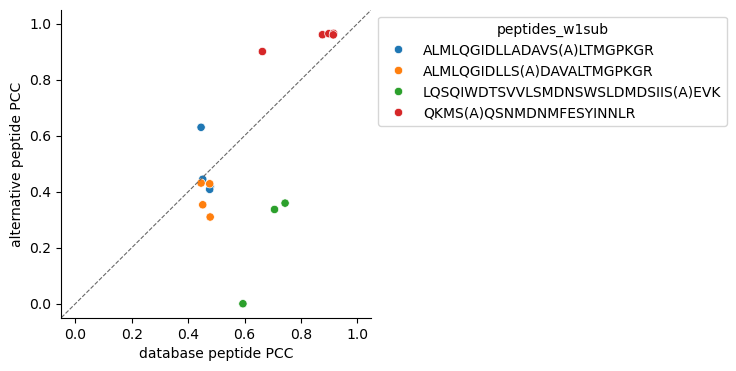

In [70]:
data = original.merge(predicted,on=['database_peptide','spectrum_title'],how='outer',suffixes=('_db','_var'))
# where none of the matches were found
data['PCC'] = data['PCC'].fillna(0)

fig, ax = plt.subplots(figsize=(4,4))
g = sns.scatterplot(data=data,x='by-intensity-pattern-correlation',y='PCC',hue='peptides_w1sub',legend=True)
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
ax.axline([0, 0], [1, 1], linewidth=0.8, linestyle="--",color="dimgrey")
ax.set_xlabel("database peptide PCC")
ax.set_ylabel("alternative peptide PCC")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Change section titles in the legend
legend = ax.get_legend()
legend_texts = legend.get_texts()
for i, txt in enumerate(legend_texts):
    peptides_w1sub = txt.get_text()
    database_peptide = data[data.peptides_w1sub==peptides_w1sub].database_peptide.iloc[0]
    label = ''.join([ a1 if a1==a2 else f'{a1}({a2})'for a1,a2 in zip(peptides_w1sub,database_peptide)])
    txt.set_text(label)  # update it
plt.savefig(f"{plot_dir}/nc_passhpp_isosaav_gnomad.svg", format='svg', bbox_inches='tight')

In [125]:
data.groupby('peptides_w1sub').apply(lambda x: np.mean(x['by-intensity-pattern-correlation']-x['PCC']))

peptides_w1sub
ALMLQGIDLLADAVSLTMGPKGR          -0.012107
ALMLQGIDLLSDAVALTMGPKGR           0.082502
LQSQIWDTSVVLSMDNSWSLDMDSIISEVK    0.449760
QKMSQSNMDNMFESYINNLR             -0.096530
dtype: float64

In [93]:
# are the alternative peptides comming from database or they are new? - new

In [90]:
insituPEP = pd.read_csv("./../../../junk/insitu_peptides.csv")

In [91]:
insituPEP[insituPEP.peptide.isin(predicted.peptides_w1sub.unique().tolist())]

,Unnamed: 0.1,Unnamed: 0,key,peptide,isUnique,protein,peptide_length,peptide_position,protein_class,peptide_class,peptide_start_relative_position,peptide_mass


In [92]:
del insituPEP

In [95]:
# are these peptides seen in Peptide Atlass?
# check with ProteoMapper, build Human 2025-01
# >>> zero mappings - totaly new peptides

In [71]:
# all had isoSAAV
#manualy checked which peptides with isosaav have missence variants in population
# exclude this
remove=list(peptide_gnomad.keys())###+peptides_with_allpsm_isosaav
psmpep_prnc_pepfilt = psmpep_prnc_pepfilt[~psmpep_prnc_pepfilt.database_peptide.isin(remove)]
psmpep_prnc_pepfilt=is_2pep(psmpep_prnc_pepfilt)
psmpep_prnc["2pep1_isosaav"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())

hpp_countdown=track_hpp_countdown(hpp_countdown, "2pep1_isosaav", psmpep_prnc_pepfilt, psmpep_prnc)

### HPP guidlines PSM level

#### Proteotypic peptides with isoSAAV explained by other peptide in database

In [72]:
#check that substitution location is on expected residue

psmpep_prnc_pepfilt["isSubAA"]=np.nan
psmpep_prnc_pepfilt["isSubMass"]=np.nan
for i, row in psmpep_prnc_pepfilt[psmpep_prnc_pepfilt.isSubstitution].iterrows():
    modifications_masses=row.modifications_masses
    for pos, aa, mass in modifications_masses:
        info=unimod_df_subs[unimod_df_subs.mono_mass==mass]
        if len(info[info.residues.str.contains(aa)]):
            psmpep_prnc_pepfilt.loc[i,["isSubAA","isSubMass"]]=[aa,mass]
print("number of peptides with expected PTM-residue pair",psmpep_prnc_pepfilt[psmpep_prnc_pepfilt.isSubstitution].isSubAA.isna().value_counts())

number of peptides with expected PTM-residue pair isSubAA
True    4
Name: count, dtype: int64


In [73]:
insituPEP = pd.read_csv("./../../../junk/insitu_peptides.csv")

In [74]:
#however, we are not sure if location is correct, so get mass and compare it to shared peptides of same mass with 1-aa distance
# mass is already available in column peptide_mass (includes mass shift)

mass_error=0.001000
for i, row in psmpep_prnc_pepfilt[psmpep_prnc_pepfilt.isSubstitution].iterrows():
    peptide_length=len(row.database_peptide)
    peptide_mass=row.peptide_mass
    candidates=insituPEP.loc[((insituPEP.peptide!=row.database_peptide)&(insituPEP.peptide_length==peptide_length)&(abs(insituPEP.peptide_mass-peptide_mass)<=mass_error))]
    #dedupl
    candidates.drop_duplicates("peptide",inplace=True)
    #check for 1 aa distance
    ham=1/peptide_length
    candidates["1_aa_dist"]=candidates.peptide.apply(lambda x: distance.hamming(list(x),list(row.database_peptide))<=ham)
    psmpep_prnc_pepfilt.loc[i,["1_aa_dist"]]="|".join(candidates[candidates["1_aa_dist"]].peptide.tolist()) if len(candidates[candidates["1_aa_dist"]])>0 else False

/tmp/ipykernel_202818/204190036.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates.drop_duplicates("peptide",inplace=True)
/tmp/ipykernel_202818/204190036.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  candidates["1_aa_dist"]=candidates.peptide.apply(lambda x: distance.hamming(list(x),list(row.database_peptide))<=ham)
/tmp/ipykernel_202818/204190036.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/index

In [75]:
del insituPEP

In [76]:
#how many non-canonical proteorypic peptides with isoSAAV can be explained by canonical or shared peptide in database
psmpep_prnc_pepfilt.loc[psmpep_prnc_pepfilt.isSubstitution][["1_aa_dist"]].value_counts() # none

1_aa_dist
False        4
Name: count, dtype: int64

In [77]:
# how many peptides had non-expected residue location with substitution, but found SAAV canonical peptide
psmpep_prnc_pepfilt[(psmpep_prnc_pepfilt.isSubstitution)&(
    psmpep_prnc_pepfilt["1_aa_dist"]!=False)&(psmpep_prnc_pepfilt.isSubAA.isna())][["database_peptide","modifications_masses","1_aa_dist"]]
#acetylation, with substitutions in S->T ; G->A ; V->I ; but different location
#how do we treat this instanses??? 
#If location is predicted diferent, but peptide mass is very similar, then it is a question of location prediction quality aka spectra qc
# so leave them for manual asessment

,database_peptide,modifications_masses,1_aa_dist


In [78]:
# no changes for last step, so skip filtering
psmpep_prnc_pepfilt=is_2pep(psmpep_prnc_pepfilt)
psmpep_prnc["2pep1_fp"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())

hpp_countdown=track_hpp_countdown(hpp_countdown, "2pep1_fp", psmpep_prnc_pepfilt, psmpep_prnc)

#### Manual validaition (best-scoring PSM per peptide)

In [79]:
psmpep_prnc_pepfilt.database_peptide.unique()

array(['MSTKIGGIGTVPVGR', 'QLEDGCTLSDYSIQKESTLHLVLR',
       'SVEMHHEALSETLSGDNVGFNVK', 'IEGEIIVCAAYAHELPK',
       'MEVTGDEYNVENIDGQPGAFTCYLDAGLAR', 'TITLEAEPLDTIENVK'], dtype=object)

In [80]:
psmpep_prnc_pepfilt.leadprot.unique()

array(['IP_762589', 'IP_592206', 'IP_572520'], dtype=object)

In [81]:
leave = ['MSTKIGGIGTVPVGR','TITLEAEPLDTIENVK']
psmpep_prnc_pepfilt = psmpep_prnc_pepfilt[psmpep_prnc_pepfilt.database_peptide.isin(leave)]
psmpep_prnc["spec"] = psmpep_prnc["database_peptide"].isin(psmpep_prnc_pepfilt["database_peptide"].tolist())

hpp_countdown=track_hpp_countdown(hpp_countdown, "spec", psmpep_prnc_pepfilt, psmpep_prnc)

### Visualise filtering steps

In [83]:
def sankey_stepwise(df, column_name,figsave_folder,wildcard):
    steps = df.index.tolist()
    source_steps = steps[:-1]
    target_steps = steps[1:]
    
    source_labels = [f'{column_name.upper()}:{s}' for s in source_steps]
    target_labels = [f'{column_name.upper()}:{s}' for s in target_steps]
    
    all_labels = list(pd.unique(source_labels + target_labels))
    label_map = {l: i for i, l in enumerate(all_labels)}
    
    values = [df.loc[target, column_name] for target in target_steps]

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_labels,
        ),
        link=dict(
            source=[label_map[s] for s in source_labels],
            target=[label_map[t] for t in target_labels],
            value=values
        )
    )])

    fig.update_layout(title_text=f"Filtering in {column_name.upper()} steps", font_size=10)
    fig.write_image(f"{figsave_folder}/S_{wildcard}_hpp_countdown_{column_name}.svg")
    fig.show()

In [84]:
hpp_countdown_df = pd.DataFrame(hpp_countdown)
hpp_countdown_df.index.name = 'step'
hpp_countdown_df

,psm,pep,prot
step,,,
original,4568,528,420
<9aa,4422,515,412
nested,3429,449,412
<18aa,3429,449,412
uniqness,977,150,144
2pep1,113,12,6
2pep1_isosaav,40,6,3
2pep1_fp,40,6,3
spec,10,2,2


In [159]:
(449-150)/(528-12)

0.5794573643410853

In [163]:
psmpep_prnc[psmpep_prnc['2pep1_fp']].value_counts('database_peptide').value_counts()

count
2     2
24    1
8     1
3     1
1     1
Name: count, dtype: int64

In [164]:
4/6

0.6666666666666666

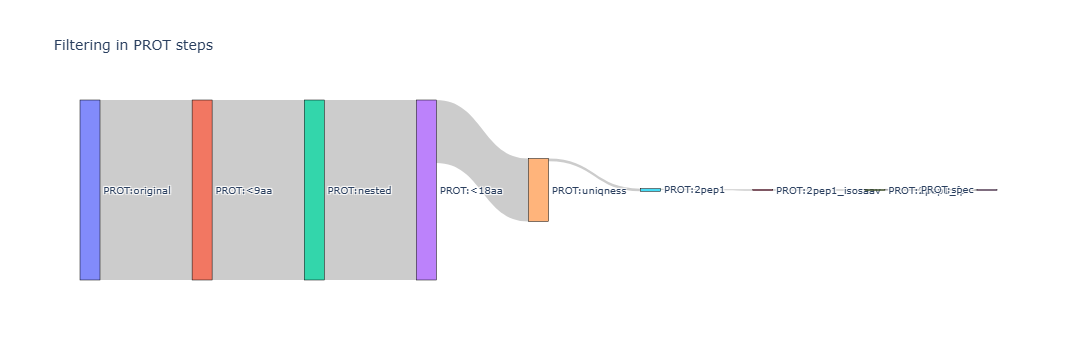

In [85]:
sankey_stepwise(hpp_countdown_df, 'prot',plot_dir,"hpp")

In [86]:
psmpep_prnc_pepfilt

,ionbot_match_id,spectrum_title,scan,spectrum_file,precursor_mass,peptide_mass,observed_retention_time,charge,database_peptide,matched_peptide,...,isSubstitution,masses_classification,NonNested,overlap_intervals,Peptide,NoMatch,isProt2Pep,isSubAA,isSubMass,1_aa_dist
464,0_14866_2,AM12:controllerType=0 controllerNumber=1 scan=...,20389,AM12,1535.726952,1529.823586,3253.25136,3,MSTKIGGIGTVPVGR,MSTKIGGIGTVPVGR,...,True,"[[Chemical derivative, AA substitution], [Mult...",True,True,MSTKIGGIGTVPVGR,True,True,NaN,NaN,False
752,4_12262_1,ESC-HF-SampleHela5:controllerType=0 controller...,14509,SampleHela,1786.925350,1784.940762,1560.48600,2,TITLEAEPLDTIENVK,TITLEAEPLDTIENVK,...,False,[[]],True,True,TITLEAEPLDTIENVK,True,True,NaN,NaN,NaN


In [97]:
# why this good spectra did not go through HPP guidlines?
#'VLNNM[+15.9949]ET[+13.0316]GTSLFDEEGAK'
prot = pep_filt[pep_filt['database_peptide']=='VLNNMETGTSLFDEEGAK'].leadprot.iloc[0]
pep_filt[pep_filt['leadprot']==prot] # only this peptide was detected per prot

,ionbot_match_id,spectrum_title,scan,spectrum_file,precursor_mass,peptide_mass,observed_retention_time,charge,database_peptide,matched_peptide,...,FDRGroup,group_qval,global_rank,global_max_rank,subset_rank,subset_max_rank,search_database,dataset,isProteotypic,peptide_class
15540,0_17899_1,controllerType=0 controllerNumber=1 scan=24032,24032,AM16,1982.931493,1982.925507,3738.82032,2,VLNNMETGTSLFDEEGAK,VLNNMETGTSLFDEEGAK,...,NonCanonical,0.002155,559.0,True,2.0,True,openprot,PXD005833.v0.11.4,True,unique_to_Noncanon
13769,0_17314_1,controllerType=0 controllerNumber=1 scan=23497,23497,AM20,1982.933325,1982.925507,3750.08658,2,VLNNMETGTSLFDEEGAK,VLNNMETGTSLFDEEGAK,...,NonCanonical,0.003259,668.0,True,5.0,True,openprot,PXD005833.v0.11.4,True,unique_to_Noncanon


### Save filtering steps on PSM level

In [146]:
# save for supplamentary and traking manual validation
pep_filt_best = pd.read_csv(f"{plot_dir}/S_nc_fdp_pass_bests_info.tsv",sep='\t')

In [149]:
psmpep_prnc_tosave = psmpep_prnc.copy(deep=True)
psmpep_prnc_tosave = psmpep_prnc_tosave.merge(pep_filt_best[['ionbot_match_id', 'spectrum_title', 'scan', 'spectrum_file',
                                                            '1_aa_dist', 'isBest', 'spectrum_file_mzxml',
                                                           'database_peptide_spectrum_utils', 'database_peptide_USI', 'PCC', 'SCC',
                                                           'broken_bounds']], 
                                                          on=['ionbot_match_id', 'spectrum_title', 'scan', 'spectrum_file'], 
                                              how='left')

In [150]:
len(psmpep_prnc),len(psmpep_prnc_tosave)

(4568, 4568)

In [152]:
psmpep_prnc_tosave.to_csv(f"{plot_dir}/S_nc_fdp_pass_info.tsv",index=False,sep='\t')

### How many proteins out of detected could theoreticaly pass HPP?

In [188]:
def is_nonnested_theor(df):
    '''Filteres out sub-peptides. Apply only on proteotypic peptides.'''
    df["NonNested"] = df.groupby("protein")["peptide_position"].transform(
        lambda intervals: filter_nested_intervals(intervals.values)
    )
    return df[df["NonNested"]]

def is_nonoverlap_theor(df):
    df = df.groupby("protein", group_keys=False).apply(mark_overlaps)
    return df[df.overlap_intervals]

def is_2pep_theor(df):
    df["isProt2Pep"]=df.protein.apply(lambda x: check_2_pep(df.groupby("protein").get_group(x)))
    return df[df.isProt2Pep]

In [183]:
insituPEP = pd.read_csv("./../../../junk/insitu_peptides.csv")
insituPEP = insituPEP[insituPEP.protein.isin(psmpep_prnc.leadprot.unique().tolist())]
insituPEP = insituPEP[insituPEP.isUnique]
insituPEP['peptide_position'] = insituPEP['peptide_position'].apply(lambda x: ast.literal_eval(x))
insituPEP['peptide_position'] = insituPEP['peptide_position'].apply(lambda x: x[0])

In [184]:
insituPEP.tail().iloc[0].peptide_position                                   

(121, 148)

In [185]:
psmpep_prnc.iloc[0].peptide_position   

(27, 56)

In [189]:
insituPEP_pepfilt=insituPEP.copy(deep=True)
#Go to peptide level - leave 1 PSM per peptide
insituPEP_pepfilt.drop_duplicates("peptide",inplace=True)
#Filter out peptides <9 aa long
insituPEP_pepfilt=is_goodlength(insituPEP_pepfilt)
#Filter out nested peptides
insituPEP_pepfilt=is_nonnested_theor(insituPEP_pepfilt)
#For overlapping peptides, check the total extent length is >=18
insituPEP_pepfilt=is_nonoverlap_theor(insituPEP_pepfilt)
# skip uniqness check as tit is too many
#check for unique 2 peptides, filterout if not
insituPEP_pepfilt=is_2pep_theor(insituPEP_pepfilt)

In [193]:
len(insituPEP_pepfilt.protein.unique())/420

0.8976190476190476

In [192]:
del insituPEP

In [203]:
#psmpep_prnc[psmpep_prnc.database_peptide=='MSTKIGGIGTVPVGR'].iloc[0]

In [207]:
#isosaaav_info[isosaaav_info.database_peptide=='MSTKIGGIGTVPVGR'].iloc[0]